# End-to-end walkthrough: from genome to plotted domain

This notebook takes you from "I have nothing on disk" to "I have a domain
mapped onto its genomic exon structure and rendered as a figure", in four
steps:

1. **Fetch** a stock index with one command (`fastCDS fetch`).
2. **Prepare** a BED of domain coordinates from one of the supported sources
   (UniProt features, InterProScan, HMMER/Pfam, or a custom TSV).
3. **Map** the BED to genomic / transcript coordinates.
4. **Plot** the result.

For the live mapping demo we use *S. cerevisiae* - the index is ~2 MB and
the whole step runs in seconds. For the plot showcases (steps 4-8) we
switch to a small **TP53 fixture** shipped with the repo
(`examples/tp53_isoforms.tsv`) so the figures show a realistic human
multi-exon architecture without needing the 250 MB human GTF download.

The same flow works unchanged for any species - swap
`fetch yeast` for `fetch human` (or similar)
and your protein IDs become ENSPs.

## Setup

Assumes you've installed fastCDS via one of:

```bash
pip install fastCDS      # includes the interactive HTML viewer
# or
mamba install -c bioconda fastCDS
# or
pixi add fastCDS
```

That puts both the C++ binary and the Python wrapper on your `$PATH`.

In [1]:
from pathlib import Path

# Find tutorial/ (this notebook's home) so the bundled examples/ fixture
# and a scratch dir resolve wherever you launch from. If you installed via
# pip and only want the API, set HERE = Path.cwd() and skip the TP53 fixture.
HERE = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "examples" / "tp53_isoforms.tsv").exists()), Path.cwd())
WORK = HERE / "_walkthrough_out"
WORK.mkdir(exist_ok=True)

import fastCDS as fc
print("fastCDS", fc.__version__)
print("work     :", WORK)

fastCDS 2.3.0
work     : /home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out


## 1. Fetch a stock index

`fastCDS fetch` downloads the right GTF, gunzips it, runs `--build-index`,
and prints the resulting `.idx` path on stdout. It caches under
`~/.cache/fastCDS/`, so re-running is a no-op.

We tell it to use a notebook-local cache so this doesn't litter your home
directory.

In [2]:
IDX = fc.fetch_index("yeast", cache_dir=WORK / "cache")
print(f"\nindex ready: {IDX}  ({IDX.stat().st_size / 1024:.0f} KB)")

downloading https://zenodo.org/records/21266614/files/refseq_R64_yeast.idx
  -> /home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/cache/yeast.idx


/home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/cache/yeast.idx

index ready: /home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/cache/yeast.idx  (1362 KB)


  done (1.3 MB)
sha256 OK (201aeff2539d7b54...)
ready: /home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/cache/yeast.idx


## 2. Prepare a BED - option A: write it by hand

If you already have the protein IDs + aa ranges you want to map (a hand-curated
list, a few genes of interest, custom proteins you appended to the GTF), the
simplest
path is to write the queries directly. Each row is
`protein_id  aa_start  aa_end  [domain_id]`.

In [3]:
bed_manual = WORK / "manual.bed"
bed_manual.write_text("\n".join([
    # Pick a few well-characterised yeast proteins - the index has 6,021 of
    # them. PAU8 is short (120 aa), SEO1 is longer (593 aa).
    "NP_009332.1\t1\t50\tPAU8_Nterm",
    "NP_009333.1\t1\t100\tSEO1_TM_helix",
    "NP_009333.1\t450\t590\tSEO1_Cterm",
]) + "\n")
print(bed_manual.read_text())

NP_009332.1	1	50	PAU8_Nterm
NP_009333.1	1	100	SEO1_TM_helix
NP_009333.1	450	590	SEO1_Cterm



## 2 (alternative). Prepare a BED - option B: from domain databases

If you already have domain hits from one of the common tools, the same
preparation logic the CLI scripts use is also exposed as a Python API
under `fastCDS.prepare` - each `from_*` function returns a pandas
DataFrame with the canonical columns `protein_id, aa_start, aa_end,
domain_id, description`. The DataFrame is consumed directly by
`Mapper.map_batch()`.

```python
import fastCDS as fc

# HMMER --domtblout (e.g. hmmscan against Pfam-A.hmm)
queries = fc.prepare.from_pfam("pfam_hits.dom", mode="scan", id_type="ensp")

# InterProScan TSV (the `-f TSV` output)
queries = fc.prepare.from_interproscan("interpro.tsv", analyses={"Pfam", "SMART"})

# UniProt feature table (.dat flat-file or REST .json)
queries = fc.prepare.from_uniprot_features("uniprot.dat")

# If your file uses UniProt accessions and you need the Ensembl xref:
mapping = fc.prepare.load_uniprot_mapping("Homo_sapiens.GRCh38.110.uniprot.tsv")
queries = fc.prepare.from_pfam("pfam_hits.dom", id_type="uniprot", mapping=mapping)

mapper.map_batch(queries)
```

The matching CLI helpers (`scripts/prepare_from_pfam.py` /
`prepare_from_interpro.py` / `prepare_from_uniprot_features.py`) share the
same parsing code, so the Python API and the CLI never drift apart.

## 3. Map the BED

The high-level Python API is one call. It writes the binary's outputs to a
temp dir, reads the TSVs back as DataFrames, and tears the dir down.

In [4]:
import fastCDS as fc

mapper = fc.Mapper(index=str(IDX))
result = mapper.map_batch([
    {"protein_id": "NP_009332.1", "aa_start": 1,   "aa_end": 50,  "domain_id": "PAU8_Nterm"},
    {"protein_id": "NP_009333.1", "aa_start": 1,   "aa_end": 100, "domain_id": "SEO1_TM_helix"},
    {"protein_id": "NP_009333.1", "aa_start": 450, "aa_end": 590, "domain_id": "SEO1_Cterm"},
])
print(f"mapped {result.n_mapped} / {result.n_total} queries")
result.summary[["input_id", "gene_name", "chrom", "strand",
                "domain_genomic_start", "domain_genomic_end",
                "n_coding_segments", "status"]]

mapped 3 / 3 queries


,input_id,gene_name,chrom,strand,domain_genomic_start,domain_genomic_end,n_coding_segments,status
0,PAU8_Nterm,PAU8,NC_001133.9,-,2020,2169,1,ok
1,SEO1_TM_helix,SEO1,NC_001133.9,-,8717,9016,1,ok
2,SEO1_Cterm,SEO1,NC_001133.9,-,7247,7669,1,ok


For large input sets (millions of queries), pass
`Mapper(..., batch_size=10000)` to cap RAM at the cost of a small overhead.
See the README's "Capping peak RAM with --batch-size" section for the
1M-query benchmark.

## 4. Load the TP53 fixture for plotting

The yeast `result` above proves the mapping pipeline works. For the
plot showcases we switch to a small **TP53 fixture** so the figures
show a real human multi-exon architecture without needing to fetch the
250 MB human GTF.

`examples/tp53_isoforms.tsv` ships four TP53 isoforms (canonical +
three alternatives) pre-mapped against the DNA-binding domain (aa
102-292). It's a regular `isoform_structure.tsv` - the plotter doesn't
care that it came from a fixture file rather than a live `Mapper`
call.

In [5]:
import pandas as pd

tp53 = pd.read_csv(HERE / "examples" / "tp53_isoforms.tsv", sep="\t")
print("TP53 isoforms in fixture:")
for iid, rows in tp53.groupby("input_id", sort=False):
    print(f"  {iid:18s}  {rows['protein_id'].iloc[0]}  ({len(rows)} CDS/UTR/intron rows)")

TP53 isoforms in fixture:
  TP53_canonical      ENSP00000269305  (25 CDS/UTR/intron rows)
  TP53_iso2           ENSP00000425104  (18 CDS/UTR/intron rows)
  TP53_iso3           ENSP00000477531  (18 CDS/UTR/intron rows)
  TP53_iso4           ENSP00000482222  (26 CDS/UTR/intron rows)


## 5. Plot the canonical TP53 isoform (matplotlib)

`fc.plot()` renders a single isoform with the CDS/UTR/intron structure
and highlights the domain envelope. PDF / PNG / SVG are all supported
via the file extension.

wrote /home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/TP53_canonical.pdf (16 KB)


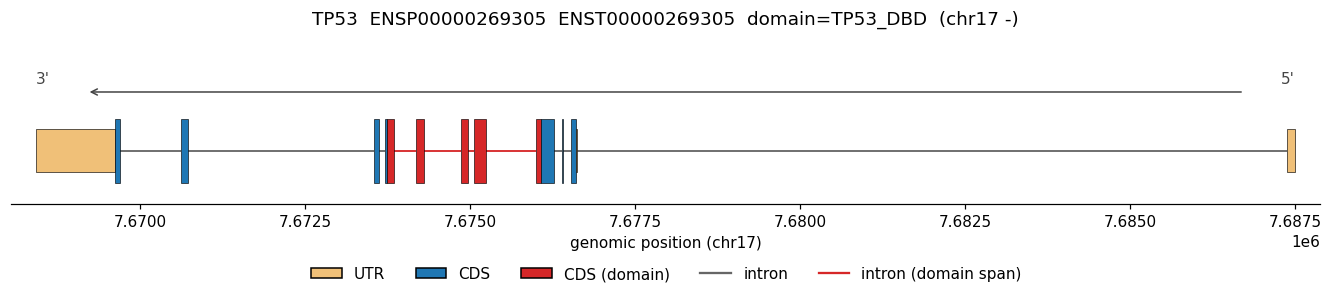

In [6]:
import io
from IPython.display import Image
out_pdf = WORK / "TP53_canonical.pdf"
fig = fc.plot(tp53, input_id="TP53_canonical")   # the matplotlib Figure
fig.savefig(str(out_pdf))                         # ...saved as a vector PDF
_buf = io.BytesIO(); fig.savefig(_buf, format="png", dpi=110, bbox_inches="tight")
print(f"wrote {out_pdf} ({out_pdf.stat().st_size / 1024:.0f} KB)")
Image(_buf.getvalue())   # show the static plot inline


## 6. Compact-genomic mode

TP53 spans ~19 kb but the CDS only adds up to ~1.2 kb - most of the
locus is intronic. Drawn to true genomic scale, the exons collapse into
slivers. `compact_genomic=True` clamps every intron to a fixed width
(80 bp) while keeping CDS / UTR true-scale, so the exon architecture
stays legible.

wrote /home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/TP53_canonical_compact.pdf (17 KB)


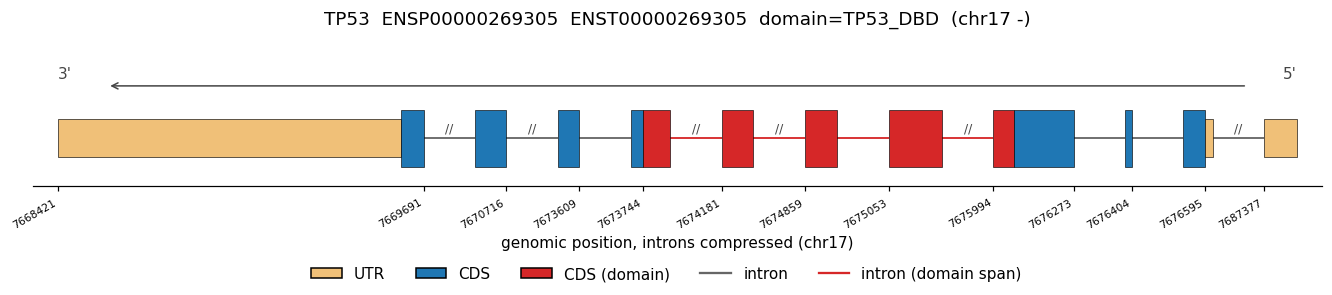

In [7]:
out_compact = WORK / "TP53_canonical_compact.pdf"
fig = fc.plot(tp53, input_id="TP53_canonical", compact_genomic=True)
fig.savefig(str(out_compact))
_buf = io.BytesIO(); fig.savefig(_buf, format="png", dpi=110, bbox_inches="tight")
print(f"wrote {out_compact} ({out_compact.stat().st_size / 1024:.0f} KB)")
Image(_buf.getvalue())   # show the compact-genomic view inline


## 7. Interactive viewer (standalone HTML)

For an interactive view that pans / zooms in any browser - without
needing plotly - render the vanilla-JS viewer. The output is a
single self-contained HTML file (no CDN, no JS deps); it works offline
and embeds in any host doc.

Gestures: **drag** = box-zoom, **shift-drag** = pan, **scroll** = wheel
zoom around the cursor, **double-click** = reset, and the minimap below
has a draggable viewport rectangle with resize handles.

In [8]:
out_html = WORK / "TP53_canonical.html"
fc.plot(tp53, input_id="TP53_canonical",
         out=str(out_html),   # .html -> interactive viewer; engine="js" is the default,
         link_template="https://www.ensembl.org/Homo_sapiens/Transcript/ProteinSummary?p={protein_id}")
print(f"wrote {out_html} ({out_html.stat().st_size / 1024:.0f} KB)")
# In a live Jupyter session, FileLink renders a clickable link that
# opens the standalone HTML in a new tab. Path is relative to the
# notebook's own directory so it resolves correctly in the Jupyter UI.
from IPython.display import FileLink
FileLink(str(out_html.relative_to(HERE)))

wrote /home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/TP53_canonical.html (39 KB)


/home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/TP53_canonical.html

## 8. Embed the viewer inline in this notebook

If you'd rather see the viewer right here, `render_interactive_jupyter()`
returns an `IPython.display.HTML` wrapping the same viewer in a
sandboxed iframe. By default the iframe auto-sizes to its content (no
inner scrollbar); pass `height=...` to pin a static height or bump
`plot_height` for a taller main track.

In [9]:
fc.render_interactive_jupyter(
    tp53, input_id="TP53_canonical",
    plot_height=160,
    link_template="https://www.ensembl.org/Homo_sapiens/Transcript/ProteinSummary?p={protein_id}",
)

## 9. Multi-isoform stack (all four TP53 transcripts at once)

Real proteins usually have multiple isoforms. The stack viewer renders
them on a **single shared axis** built from the union of all isoforms'
features - so a CDS at the same genomic position lines up vertically
across rows, and gaps (skipped exons) appear as empty space in the same
coordinate column. Same gestures as the single-isoform viewer
(drag = box-zoom, shift-drag = pan, wheel zoom, draggable minimap).

In [10]:
fc.render_interactive_jupyter_stack(
    tp53,                                              # the whole fixture, all isoforms
    plot_height=44,
    link_template="https://www.ensembl.org/Homo_sapiens/Transcript/ProteinSummary?p={protein_id}",
)

## 10. Compare against the plotly viewer

For reference, `fc.plot(..., out="x.html", engine="plotly")` writes a plotly-based viewer
with a rangeslider and full hover tooltips. It's the same data, a
different aesthetic - useful when you want all the plotly affordances
(legend toggling, image export, etc.). We render it to a file and embed
it inline below.

In [11]:
from IPython.display import HTML
out_plotly = WORK / "TP53_canonical_plotly.html"
fc.plot(tp53, input_id="TP53_canonical", out=str(out_plotly), engine="plotly",
         link_template="https://www.ensembl.org/Homo_sapiens/Transcript/ProteinSummary?p={protein_id}")
print(f"wrote {out_plotly} ({out_plotly.stat().st_size / 1024:.0f} KB)")
# Inline via srcdoc so the rendered notebook stays self-contained even
# when nbconvert-exported to a directory that no longer has the file
# next to it.
_plotly_html = out_plotly.read_text()
_escaped = _plotly_html.replace("&", "&amp;").replace('"', "&quot;")
HTML('<div><iframe srcdoc="' + _escaped + '" '
     'style="width:100%; height:540px; border:none;" '
     'sandbox="allow-scripts"></iframe></div>')

wrote /home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/TP53_canonical_plotly.html (12 KB)


Wrote /home/goguxor/Desktop/fastCDS/tutorial/_walkthrough_out/TP53_canonical_plotly.html


For multi-isoform views (one row per isoform, all in one figure):

```python
fc.plot(result, all=True, out="all_isoforms.pdf")
```

Or render the genomic span as an IGV-ready BED12:

```python
print(result.bed12)  # already a DataFrame
result.bed12.to_csv("for_igv.bed12", sep="\t", header=False, index=False)
```

## What next?

- **Swap species** - `fastCDS fetch human`, then the same
  `Mapper(...).map_batch(...)` against your domain BED. Everything else stays
  the same.
- **Larger inputs** - bulk-process millions of queries by passing
  `Mapper(..., batch_size=10000, threads=4)`. Output files end up in the
  `keep_outputs` dir for downstream analysis.
- **Custom proteins** - append new entries to your GTF before indexing using
  `scripts/append_custom_proteins.py` (see README -> "Adding custom proteins
  to an existing GTF").
- **Plot every isoform** - pass `all=True` to `fc.plot()` to render all
  mapped queries in a single multi-panel figure.
- **Embed in a dashboard** - the standalone HTML from step 6 is a single
  file; drop it into any static site or Streamlit / Panel app.